In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as statss
from scipy import stats
# Sklearn
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold


In [42]:
red_wine=pd.read_csv("./Data_Set/winequality-red.csv",sep=";")
white_wine=pd.read_csv("./Data_Set/winequality-white.csv",sep=";")

In [43]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [44]:
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


**# NEW COLUMN**

In [45]:
red_wine2=red_wine.assign(wine_color="red")
red_wine2.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [46]:
red_wine2["quality_label"]=red_wine2["quality"].apply(lambda value:"low" if value <=5 else "medium"
if value <=7 else "high" )
red_wine2.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_color,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,low


In [47]:
white_wine2=white_wine.assign(wine_color="white")
white_wine2.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [48]:
white_wine2["quality_label"]=white_wine2["quality"].apply(lambda value: "low" if value<=5 else "medium"
if value<=7 else "high")
white_wine2.head(4)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_color,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,medium
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,medium


In [49]:
red_wine2["quality_label"]=pd.Categorical(red_wine2["quality_label"],categories=("low","medium","high"))

In [50]:
white_wine2["quality_label"]=pd.Categorical(white_wine2["quality_label"],categories=("low","medium","high"))

**Concat**

In [51]:
wines=pd.concat([red_wine2,white_wine2])
wines.shape

(6497, 14)

**DATA CLEANING**

In [52]:
wines.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_color              0
quality_label           0
dtype: int64

In [53]:
wines.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_color              0
quality_label           0
dtype: int64

In [54]:
wines.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [55]:
wines.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6497 entries, 0 to 4897
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         6497 non-null   float64 
 1   volatile acidity      6497 non-null   float64 
 2   citric acid           6497 non-null   float64 
 3   residual sugar        6497 non-null   float64 
 4   chlorides             6497 non-null   float64 
 5   free sulfur dioxide   6497 non-null   float64 
 6   total sulfur dioxide  6497 non-null   float64 
 7   density               6497 non-null   float64 
 8   pH                    6497 non-null   float64 
 9   sulphates             6497 non-null   float64 
 10  alcohol               6497 non-null   float64 
 11  quality               6497 non-null   int64   
 12  wine_color            6497 non-null   object  
 13  quality_label         6497 non-null   category
dtypes: category(1), float64(11), int64(1), object(1)
memory 

In [56]:
wines.rename(columns={"fixed acidity":"fixed_acidity","volatile acidity":"volatile_acidity","citric acid":"citric_acid","residual sugar":"residual_sugar","free sulfur dioxide":"free_sulfur_dioxide","total sulfur dioxide":"total_sulfur_dioxide"},inplace=True)

MACHINE LEARNING
ENCODING

In [57]:
le=LabelEncoder()

In [58]:
white_wine2["Quality_Cat"]=le.fit_transform(white_wine2["quality_label"])

In [59]:

white_wine2[white_wine2["Quality_Cat"] == 1] 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_color,quality_label,Quality_Cat
10,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.99080,2.99,0.56,12.0,5,white,low,1
11,8.6,0.23,0.40,4.20,0.035,17.0,109.0,0.99470,3.14,0.53,9.7,5,white,low,1
12,7.9,0.18,0.37,1.20,0.040,16.0,75.0,0.99200,3.18,0.63,10.8,5,white,low,1
14,8.3,0.42,0.62,19.25,0.040,41.0,172.0,1.00020,2.98,0.67,9.7,5,white,low,1
19,6.5,0.31,0.14,7.50,0.044,34.0,133.0,0.99550,3.22,0.50,9.5,5,white,low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4882,5.5,0.32,0.13,1.30,0.037,45.0,156.0,0.99184,3.26,0.38,10.7,5,white,low,1
4884,6.5,0.33,0.38,8.30,0.048,68.0,174.0,0.99492,3.14,0.50,9.6,5,white,low,1
4888,6.8,0.22,0.36,1.20,0.052,38.0,127.0,0.99330,3.04,0.54,9.2,5,white,low,1
4892,6.5,0.23,0.38,1.30,0.032,29.0,112.0,0.99298,3.29,0.54,9.7,5,white,low,1


SPLITING

In [60]:
X=white_wine2.iloc[:,[1,2,3,4,5,6,7,8,9,10]] #input
y=white_wine2.Quality_Cat #target

print(y.shape)
print(X.shape)

(4898,)
(4898, 10)


In [61]:
from random import shuffle
from sklearn.model_selection import StratifiedKFold
Kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=4898)
Kf.get_n_splits(X)


5

In [62]:
for train_index,test_index in Kf.split(X,y):
    #print("TRAIN:",train_index,"TEST:",test_index)
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y.loc[train_index], y.loc[test_index]
    
    

!!!! NORMALISATION

In [63]:
# fit scaler on training data
#norm=MinMaxScaler().fit(X_train)

In [64]:
# transform training data
#X_train_norm=norm.transform(X_train)

In [65]:
# transform testing data#
#X_test_norm=norm.transform(X_test)

In [66]:
#print(X_train_norm)

PREDICTING. Random Forest


In [67]:

RF=RandomForestClassifier(n_estimators=400)
RF.fit(X_train,y_train)

RandomForestClassifier(n_estimators=400)

In [68]:
pred_RF=RF.predict(X_test)

In [69]:
RF.predict(X_test[0:10])

array([2, 1, 2, 2, 2, 2, 1, 2, 2, 2])

In [70]:
RF.predict_proba(X_test[:10])

array([[0.01  , 0.1675, 0.8225],
       [0.    , 0.835 , 0.165 ],
       [0.    , 0.325 , 0.675 ],
       [0.025 , 0.2325, 0.7425],
       [0.025 , 0.13  , 0.845 ],
       [0.2175, 0.115 , 0.6675],
       [0.    , 0.8375, 0.1625],
       [0.0325, 0.4425, 0.525 ],
       [0.0275, 0.1475, 0.825 ],
       [0.0025, 0.345 , 0.6525]])

In [71]:
X_test[:10]

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
2,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
6,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6
8,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
9,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0
10,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0
13,0.16,0.40,1.50,0.044,48.0,143.0,0.9912,3.54,0.52,12.4
16,0.48,0.04,1.10,0.046,30.0,99.0,0.9928,3.24,0.36,9.6
18,0.34,0.42,1.10,0.033,17.0,171.0,0.9917,3.12,0.53,11.3
22,0.26,0.42,1.70,0.049,41.0,122.0,0.9930,3.47,0.48,10.5
26,0.24,0.35,1.00,0.052,35.0,146.0,0.9930,3.45,0.44,10.0


In [72]:
y_test[:10]

2     2
6     2
8     2
9     2
10    1
13    2
16    2
18    2
22    0
26    2
Name: Quality_Cat, dtype: int64

EVALUATION

In [73]:
# 0- high 
#1 - low
#2- medium
label=["high","low","medium"]
cm=confusion_matrix(y_test,pred_RF)
pd.DataFrame(cm,index=label,columns=label)

,high,low,medium
high,9,1,26
low,0,231,97
medium,0,64,551


In [74]:
print("accuracy_score -",accuracy_score(y_test,pred_RF))

accuracy_score - 0.8079673135852911


In [75]:
print(classification_report(y_test,pred_RF,target_names=["high","low","medium"]))

              precision    recall  f1-score   support

        high       1.00      0.25      0.40        36
         low       0.78      0.70      0.74       328
      medium       0.82      0.90      0.85       615

    accuracy                           0.81       979
   macro avg       0.87      0.62      0.67       979
weighted avg       0.81      0.81      0.80       979



MODEL IMPROVEMENT

In [76]:
#get importance
importance = RF.feature_importances_
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))

Feature: 0, Score: 0.12426
Feature: 1, Score: 0.08699
Feature: 2, Score: 0.09111
Feature: 3, Score: 0.09042
Feature: 4, Score: 0.10774
Feature: 5, Score: 0.09125
Feature: 6, Score: 0.11303
Feature: 7, Score: 0.08250
Feature: 8, Score: 0.07657
Feature: 9, Score: 0.13612


/Users/Yanaorfin/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


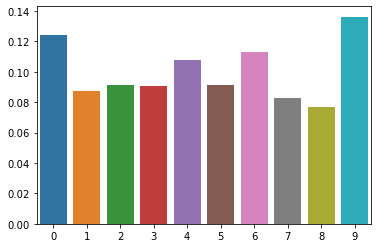

In [77]:
sns.barplot([x for x in range(len(importance))],importance)
plt.show()